# Library and Data Importation

In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# Load our raw IoT dataset
df = pd.read_csv('Raw_IoT_Carbon_Footprint_Dataset.csv')

In [77]:
df.columns

Index(['Person_ID', ' Energy_Usage_kWh   ', ' Transportation_Distance_km',
       ' Vehicle_Type    ', ' Smart_Appliance_Usage_hours',
       ' Renewable_Energy_Usage_percent', ' Building_Type',
       ' Temperature_C         ', ' Humidity_percent  ',
       ' Carbon_Emission_kgCO2'],
      dtype='str')

# Synthetic method and target modification

In [78]:
# Add Synthetic Plastic Variable
# Mean = 0.087 kg/day (Cambodian average), Scale = 0.02 for realistic variation
np.random.seed(42)
plastic_usage = np.random.normal(loc=0.087, scale=0.02, size=len(df))
plastic_usage = np.clip(plastic_usage, 0.01, None)  # Remove negative values

# Insert the new column
carbon_index = df.columns.get_loc(' Carbon_Emission_kgCO2')
df.insert(carbon_index, 'Plastic_Usage_kg', plastic_usage)

# Modify the Target Variable (Carbon_Emission_kgCO2)
# Lifecycle emission factor: 1kg plastic = ~6.0kg CO2
plastic_ef = 6.0
df[' Carbon_Emission_kgCO2'] = df[' Carbon_Emission_kgCO2'] + (df['Plastic_Usage_kg'] * plastic_ef)

# Save the modified dataset
df.to_csv('uncleaned_IoT_Carbon_Dataset.csv', index=False)

print("Plastic variable added before Carbon_Emission_kgCO2 and target variable updated successfully!")

Plastic variable added before Carbon_Emission_kgCO2 and target variable updated successfully!


# Data Inspectation

In [79]:
# Load the uncleaned dataset
df = pd.read_csv('uncleaned_IoT_Carbon_Dataset.csv')

# --- 1. Data Size ---
# Understand the complexity and volume of the data
print(f"Dataset Size: {df.shape[0]} rows and {df.shape[1]} columns")

# --- 2. Data Types ---
# Check if numbers are recognized as floats and categories as objects
print("\n--- Data Types ---")
print(df.dtypes)

# --- 3. Missing Values ---
# Ensure there are no 'NaN' values that could break the model later
print("\n--- Missing Values ---")
print(df.isnull().sum())

# --- 4. Categorical Consistency ---
# Check if 'Vehicle_Type' or 'Building_Type' has typos or inconsistent naming
print("\n--- Categorical Variables ---")
for col in df.select_dtypes(include=['object']).columns:
    print(f"Unique values in '{col}': {df[col].unique()}")


Dataset Size: 10000 rows and 11 columns

--- Data Types ---
Person_ID                            int64
 Energy_Usage_kWh                  float64
 Transportation_Distance_km        float64
 Vehicle_Type                          str
 Smart_Appliance_Usage_hours       float64
 Renewable_Energy_Usage_percent    float64
 Building_Type                         str
 Temperature_C                     float64
 Humidity_percent                  float64
Plastic_Usage_kg                   float64
 Carbon_Emission_kgCO2             float64
dtype: object

--- Missing Values ---
Person_ID                          0
 Energy_Usage_kWh                  0
 Transportation_Distance_km        0
 Vehicle_Type                      0
 Smart_Appliance_Usage_hours       0
 Renewable_Energy_Usage_percent    0
 Building_Type                     0
 Temperature_C                     0
 Humidity_percent                  0
Plastic_Usage_kg                   0
 Carbon_Emission_kgCO2             0
dtype: int64

--- Cate

/var/folders/86/4l8s2b4s5n93y597sjvnw7180000gn/T/ipykernel_3228/1067854005.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


# Handling Missing data

No missing data detected

# Data Characteristics

In [80]:
# Identify numeric and categorical columns
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include="object").columns

# Summary statistics
summary_stats = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode": df[numeric_cols].mode().iloc[0],
    "Standard Deviation": df[numeric_cols].std(),
    "Skewness": df[numeric_cols].skew(),
    "Kurtosis": df[numeric_cols].kurt(),
    "1st Quartile": df[numeric_cols].quantile(0.25),
    "3rd Quartile": df[numeric_cols].quantile(0.75),
    "Max" : df[numeric_cols].max(),
    "Min" : df[numeric_cols].min()
})

print("Summary Statistics:")
summary_stats

Summary Statistics:


/var/folders/86/4l8s2b4s5n93y597sjvnw7180000gn/T/ipykernel_3228/1013183555.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


,Mean,Median,Mode,Standard Deviation,Skewness,Kurtosis,1st Quartile,3rd Quartile,Max,Min
Person_ID,5000.500000,5000.500000,1.000000,2886.895680,0.000000,-1.200000,2500.750000,7500.250000,10000.000000,1.000000
Energy_Usage_kWh,25.719659,25.641374,2.000558,13.806246,0.024880,-1.189151,13.823786,37.520305,49.986448,2.000558
Transportation_Distance_km,50.452988,50.589678,0.015774,28.929455,-0.018445,-1.196846,25.394580,75.647922,99.992483,0.015774
Smart_Appliance_Usage_hours,6.455659,6.463859,1.000061,3.151162,0.015340,-1.190028,3.721966,9.133234,11.997683,1.000061
Renewable_Energy_Usage_percent,49.763431,49.398761,0.001674,28.947451,0.019498,-1.204342,24.681674,74.974221,99.997215,0.001674
Temperature_C,15.157229,15.304519,-9.999578,14.417064,-0.024096,-1.193226,2.847824,27.672299,39.996985,-9.999578
Humidity_percent,55.125168,55.294661,20.018909,20.136054,-0.019609,-1.199959,37.771932,72.672843,89.978291,20.018909
Plastic_Usage_kg,0.086957,0.086948,0.010000,0.020069,0.002267,0.025756,0.073548,0.100422,0.165525,0.010000
Carbon_Emission_kgCO2,23.477731,23.135779,1.852011,9.739106,0.227928,-0.412579,16.261548,30.039244,56.455184,1.852011


# Data Transformation

In [81]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Scaling (Standardization)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numeric_cols])
scaled_df = pd.DataFrame(scaled_data, columns=numeric_cols)

# Normalization (Min-Max Scaling)
minmax = MinMaxScaler()
normalized_data = minmax.fit_transform(df[numeric_cols])
normalized_df = pd.DataFrame(normalized_data, columns=numeric_cols)

# Encoding categorical variables
encoded_df = pd.get_dummies(df[categorical_cols], drop_first=True)

# Log transformation for positively skewed numeric variables
skewness = df[numeric_cols].skew()
skewed_cols = skewness[skewness > 0.75].index

for col in skewed_cols:
    if (df[col] >= 0).all():
        df[col] = np.log1p(df[col])

# Feature engineering (create new variables)
if "Energy_Usage_KWh" in df.columns and "Transportation_Distance_km" in df.columns:
    df["Energy_per_km"] = df["Energy_Usage_KWh"] / df["Transportation_Distance_km"].replace(0, np.nan)

if "Plastic_Usage_kg" in df.columns and "Energy_Usage_KWh" in df.columns:
    df["Plastic_per_energy"] = df["Plastic_Usage_kg"] / df["Energy_Usage_KWh"].replace(0, np.nan)

# Aggregation using only numeric columns
if "Vehicle_Type" in df.columns:
    vehicle_group = df.groupby("Vehicle_Type")[numeric_cols].mean()
    print("Grouped Data by Vehicle Type:")
    print(vehicle_group)

print("\nScaled Data:")
print(scaled_df.head())

print("\nNormalized Data:")
print(normalized_df.head())

print("\nEncoded Variables:")
print(encoded_df.head())


Scaled Data:
   Person_ID   Energy_Usage_kWh      Transportation_Distance_km  \
0  -1.731878             -0.415900                    -0.452465   
1  -1.731531              1.587377                    -0.593258   
2  -1.731185              0.826917                    -1.135149   
3  -1.730838              0.363328                     0.355146   
4  -1.730492             -1.175669                    -0.096466   

    Smart_Appliance_Usage_hours   Renewable_Energy_Usage_percent  \
0                     -1.408941                         0.386092   
1                     -1.519315                        -1.584781   
2                      0.377801                         0.396000   
3                      1.641261                        -1.409403   
4                      0.023572                         0.734851   

    Temperature_C            Humidity_percent    Plastic_Usage_kg  \
0                 1.193409             0.833556          0.497160   
1                -0.029923          

In [82]:
scaled_df.head()

,Person_ID,Energy_Usage_kWh,Transportation_Distance_km,Smart_Appliance_Usage_hours,Renewable_Energy_Usage_percent,Temperature_C,Humidity_percent,Plastic_Usage_kg,Carbon_Emission_kgCO2
0,-1.731878,-0.415900,-0.452465,-1.408941,0.386092,1.193409,0.833556,0.497160,-0.501519
1,-1.731531,1.587377,-0.593258,-1.519315,-1.584781,-0.029923,1.318694,-0.135676,0.849278
2,-1.731185,0.826917,-1.135149,0.377801,0.396000,-1.067119,-0.134223,0.647626,-0.110496
3,-1.730838,0.363328,0.355146,1.641261,-1.409403,0.809835,-0.739142,1.520015,0.778404
4,-1.730492,-1.175669,-0.096466,0.023572,0.734851,-0.292954,-0.636001,-0.231242,-0.537418


In [83]:
normalized_df.head()

,Person_ID,Energy_Usage_kWh,Transportation_Distance_km,Smart_Appliance_Usage_hours,Renewable_Energy_Usage_percent,Temperature_C,Humidity_percent,Plastic_Usage_kg,Carbon_Emission_kgCO2
0,0.0000,0.374639,0.373570,0.092385,0.609403,0.847286,0.741715,0.558974,0.306605
1,0.0001,0.950982,0.332832,0.060761,0.038888,0.494543,0.881343,0.477318,0.547523
2,0.0002,0.732198,0.176037,0.604317,0.612271,0.195471,0.463179,0.578389,0.376345
3,0.0003,0.598823,0.607250,0.966320,0.089656,0.736684,0.289076,0.690955,0.534883
4,0.0004,0.156053,0.476577,0.502824,0.710359,0.418698,0.318761,0.464987,0.300202


In [84]:
encoded_df.head(8)

,Vehicle_Type _ Car,Vehicle_Type _ Electric Vehicle,Vehicle_Type _ Walking,Building_Type_ Residential
0,False,False,False,False
1,False,False,False,False
2,False,True,False,True
3,True,False,False,False
4,True,False,False,False
5,False,False,True,True
6,False,True,False,False
7,False,False,True,False


## Scaled csv file

In [85]:

#  Encoding Categorical Variables (Convert Text to Numbers)
df_encoded = pd.get_dummies(df, columns=[' Vehicle_Type    ', ' Building_Type'], drop_first=True)

#  Define numeric features to be scaled
numeric_features = [
    ' Energy_Usage_kWh   ', 
    ' Transportation_Distance_km', 
    ' Smart_Appliance_Usage_hours', 
    ' Renewable_Energy_Usage_percent', 
    ' Temperature_C         ', 
    ' Humidity_percent  ', 
    'Plastic_Usage_kg'
]

#  Scaling (Standardization)
scaler = StandardScaler()
df_encoded[numeric_features] = scaler.fit_transform(df_encoded[numeric_features])

#  Finalize the dataset (Remove Person_ID)
df_scaled = df_encoded.drop(columns=['Person_ID'])

#  Save the CSV file
df_scaled.to_csv('Initial_Scaled_IoT_Carbon_Dataset.csv', index=False)

print("Initial_Scaled_IoT_Carbon_Dataset.csv has been created.")

Initial_Scaled_IoT_Carbon_Dataset.csv has been created.


# Data Visualization

## Importing Data for visualzaing

In [86]:
uncleaned_data=pd.read_csv("uncleaned_IoT_Carbon_Dataset.csv")
scaled_data=pd.read_csv("Initial_Scaled_IoT_Carbon_Dataset.csv")

## Boxplot (Numerical Variable)

### Boxplot for Energy Usage

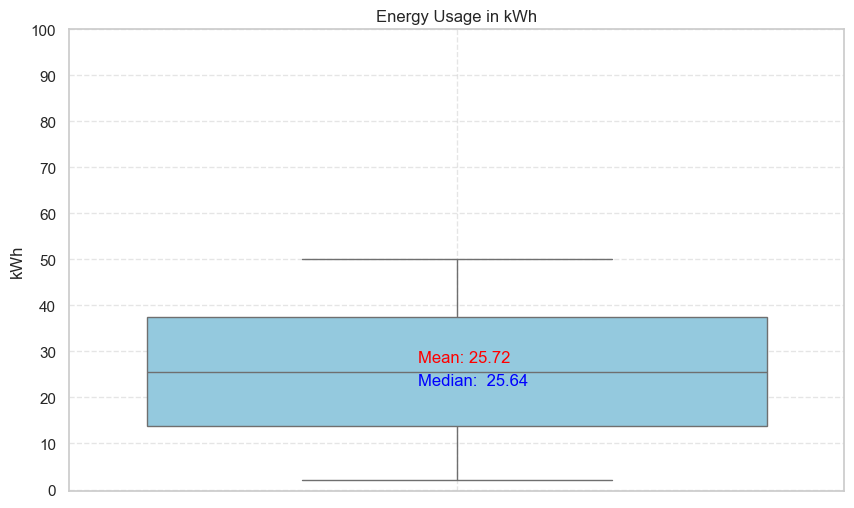

In [87]:
uncleaned_energy=uncleaned_data[" Energy_Usage_kWh   "]
plt.figure(figsize=(10,6))
sns.boxplot(y=uncleaned_energy, color='skyblue')
max_energy=uncleaned_energy.max()
plt.yticks(range(0, int(max_energy)+60, 10))
plt.text(-0.05,uncleaned_energy.mean()+2, f"Mean: {uncleaned_energy.mean():.2f}", color='red')
plt.text(-0.05, uncleaned_energy.median()-3, f"Median:  {uncleaned_energy.median():.2f}", color='blue')
plt.title("Energy Usage in kWh")
plt.ylabel("kWh")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Box Plot – Energy Usage (kWh)**

* **Range:** Energy usage ranges roughly from **2 kWh to 50 kWh**.
* **Middle 50% (IQR):** Most values fall between about **14 kWh and 37 kWh**.
* **Center:**

  * **Median ≈ 25.64 kWh**
  * **Mean ≈ 25.72 kWh**
* **Distribution:** Mean and median are very close → **distribution is fairly symmetric**.
* **Outliers:** **No clear outliers** are visible in the plot.


### Boxplot for Transportation Distance

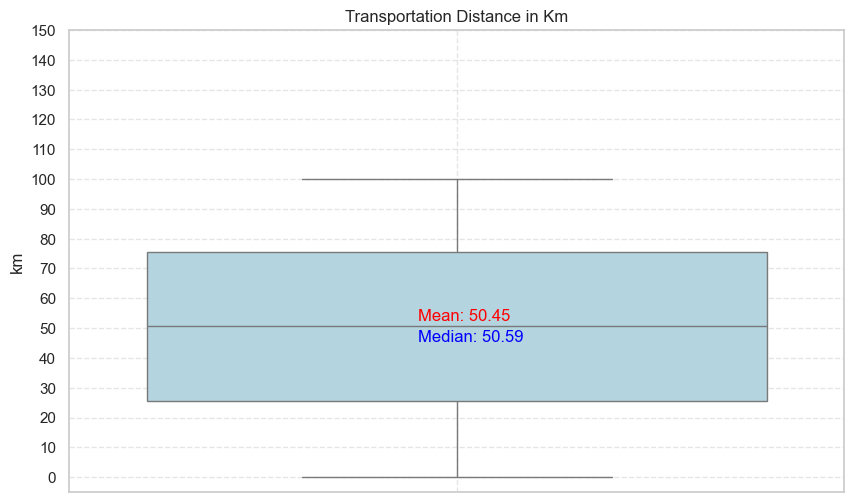

In [88]:
uncleaned_transport=uncleaned_data[" Transportation_Distance_km"]
plt.figure(figsize=(10,6))
sns.boxplot(y=uncleaned_transport, color='lightblue')
max_transport=uncleaned_transport.max()
plt.yticks(range(0, int(max_transport)+60, 10))
plt.text(-0.05,uncleaned_transport.mean()+2,f"Mean: {uncleaned_transport.mean():.2f}", color='red')
plt.text(-0.05,uncleaned_transport.median()-5,f"Median: {uncleaned_transport.median():.2f}",color='blue')
plt.title("Transportation Distance in Km")
plt.ylabel("km")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


**Box Plot – Transportation Distance (km)**

* **Range:** Transportation distance ranges from about **0 km to 100 km**.
* **Middle 50% (IQR):** Most distances fall between approximately **25 km and 75 km**.
* **Center:**

  * **Median ≈ 50.59 km**
  * **Mean ≈ 50.45 km**
* **Distribution:** Mean and median are very close → **distribution is fairly symmetric**.
* **Outliers:** **No clear outliers** are observed in the data.


### Boxplot for Smart Appliance Usage in Hours

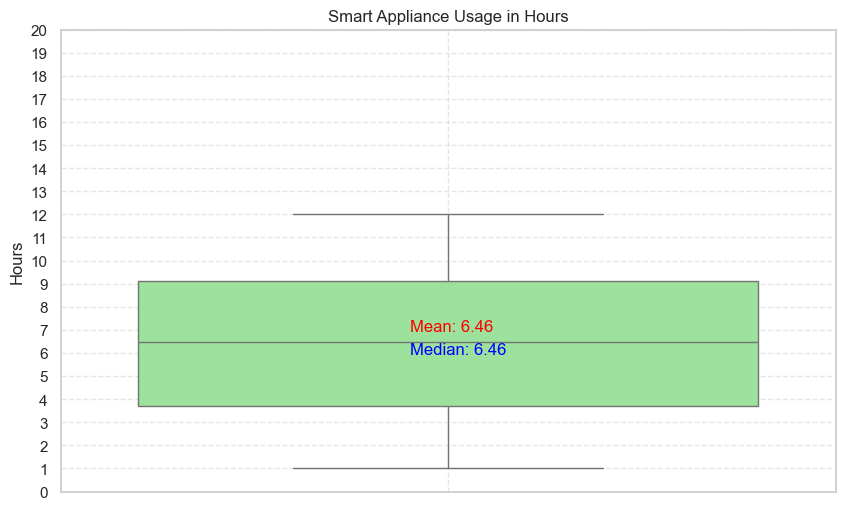

In [89]:
uncleaned_appliance=uncleaned_data[" Smart_Appliance_Usage_hours"]
plt.figure(figsize=(10,6))
sns.boxplot(y=uncleaned_appliance, color='lightgreen')
max_appliance=uncleaned_appliance.max()
plt.yticks(range(0, int(max_appliance)+10, 1))
plt.ylabel("Hours")
plt.text(-0.05, uncleaned_appliance.mean()+0.5, f"Mean: {uncleaned_appliance.mean():.2f}", color='red')
plt.text(-0.05, uncleaned_appliance.median()-0.5, f"Median: {uncleaned_appliance.median():.2f}", color='blue')
plt.title("Smart Appliance Usage in Hours")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Box Plot – Smart Appliance Usage (Hours)**

* **Range:** Usage ranges from about **1 hour to 12 hours**.
* **Middle 50% (IQR):** Most values lie between approximately **4 hours and 9 hours**.
* **Center:**

  * **Mean ≈ 6.46 hours**
  * **Median ≈ 6.46 hours**
* **Distribution:** Mean and median are equal → **very symmetric distribution**.
* **Outliers:** **No visible outliers** in the data.


### Boxplot for Temperature

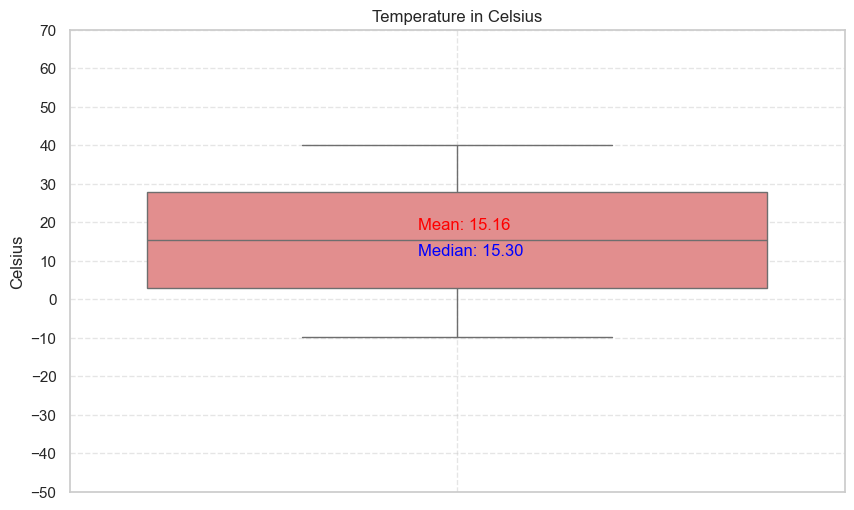

In [90]:
uncleaned_temp=uncleaned_data[" Temperature_C         "]
plt.figure(figsize=(10,6))
sns.boxplot(y=uncleaned_temp,color='lightcoral')
plt.yticks(range(-50,80,10))
plt.text(-0.05, uncleaned_temp.mean()+3, f"Mean: {uncleaned_temp.mean():.2f}", color='red')
plt.text(-0.05, uncleaned_temp.median()-4, f"Median: {uncleaned_temp.median():.2f}", color='blue')
plt.title("Temperature in Celsius")
plt.ylabel("Celsius")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Box Plot – Temperature (°C)**

* **Range:** Temperature varies from about **-10°C to 40°C**.
* **Middle 50% (IQR):** Most temperatures fall between approximately **3°C and 27°C**.
* **Center:**

  * **Median ≈ 15.30°C**
  * **Mean ≈ 15.16°C**
* **Distribution:** Mean and median are very close → **distribution is fairly symmetric**.
* **Outliers:** **No clear outliers** are observed.


### Boxplot for plastic usage

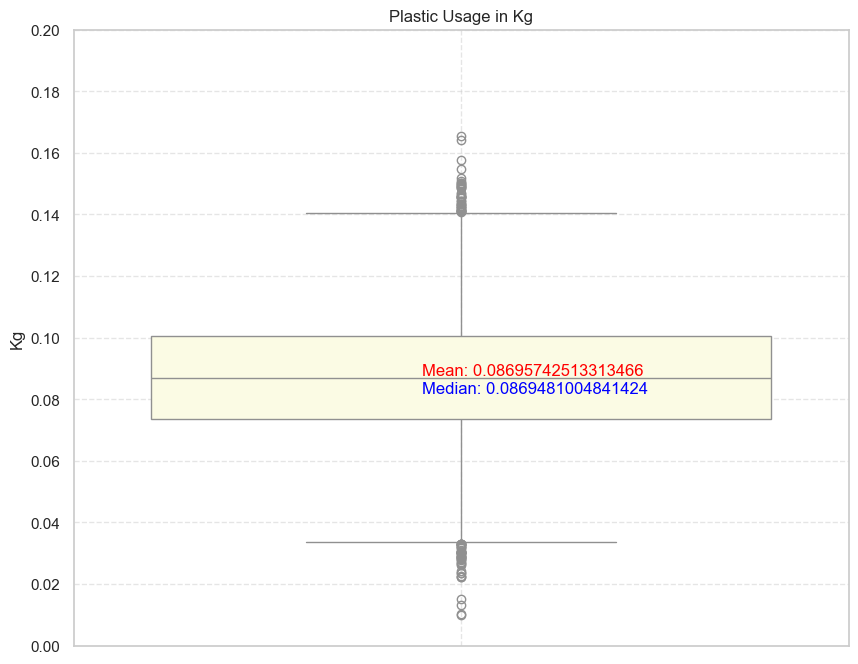

In [91]:
uncleaned_plastic=uncleaned_data["Plastic_Usage_kg"]
plt.figure(figsize=(10,8))
sns.boxplot(y=uncleaned_plastic, color='lightyellow')
plt.yticks([0,0.02,0.04,0.06,0.08, 0.1,0.12,0.14,0.16,0.18,0.2])
plt.text(-0.05,uncleaned_plastic.mean()+0.001,f"Mean: {uncleaned_plastic.mean()}",color='red')
plt.text(-0.05,uncleaned_plastic.median()-0.005,f"Median: {uncleaned_plastic.median()}",color='blue')
plt.ylabel("Kg")
plt.title("Plastic Usage in Kg")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


**Box Plot – Plastic Usage (kg)**

* **Range:** Plastic usage ranges roughly from **0.01 kg to 0.16 kg**.
* **Middle 50% (IQR):** Most values fall between about **0.07 kg and 0.10 kg**.
* **Center:**

  * **Median ≈ 0.0869 kg**
  * **Mean ≈ 0.0870 kg**
* **Distribution:** Mean and median are almost identical → **distribution is fairly symmetric**.
* **Outliers:** **Several outliers present**, both **below ~0.03 kg** and **above ~0.14 kg**, indicating some unusually low and high plastic usage values.


### Boxplot for Carbon Emission (Target)

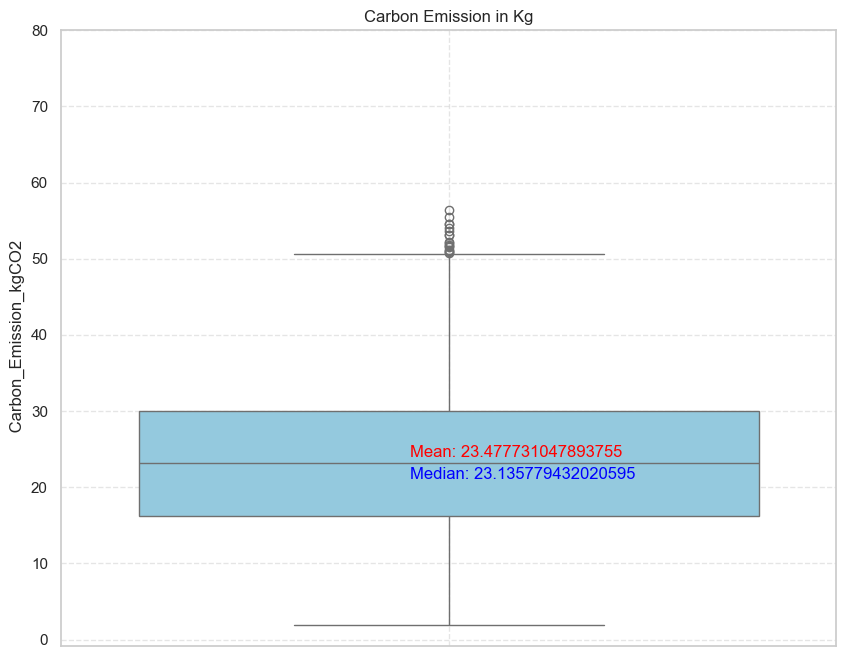

In [92]:
uncleaned_emission=uncleaned_data[" Carbon_Emission_kgCO2"]
plt.figure(figsize=(10,8))
sns.boxplot(y=uncleaned_emission, color='skyblue')
max_emission=uncleaned_emission.max()
plt.yticks(range(0,int(max_emission)+30,10))
plt.text(-0.05,uncleaned_emission.mean()+0.5,f"Mean: {uncleaned_emission.mean()}",color='red')
plt.text(-0.05,uncleaned_emission.median()-2,f"Median: {uncleaned_emission.median()}",color='blue')
plt.title("Carbon Emission in Kg")
plt.grid(True, linestyle='--',alpha=0.5)
plt.show()

**Box Plot – Carbon Emission (kg CO₂)**

* **Range:** Carbon emissions range roughly from **2 kg to 56 kg**.
* **Middle 50% (IQR):** Most values lie between about **16 kg and 30 kg**.
* **Center:**

  * **Median ≈ 23.14 kg**
  * **Mean ≈ 23.48 kg**
* **Distribution:** Mean slightly higher than median → **very slight right skew**.
* **Outliers:** **Several high outliers above ~50 kg**, indicating some unusually high emission values.


## Categorical Variable

### Vehicle Type

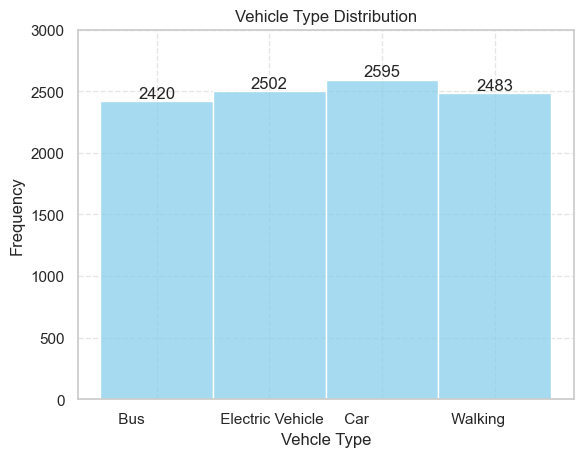

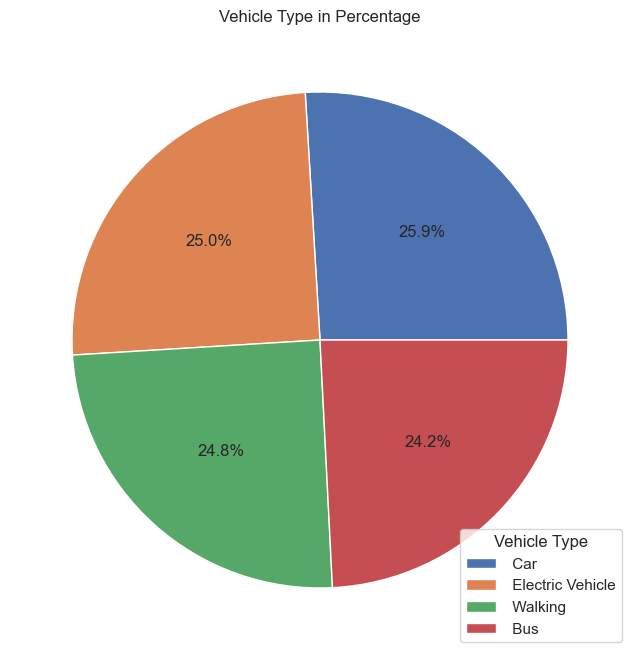

In [93]:
# Histogram for Vehicle Type
uncleaned_vehicle=uncleaned_data[" Vehicle_Type    "]
ax=sns.histplot(uncleaned_vehicle, color='skyblue')
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("Vehcle Type")
plt.ylabel("Frequency")
plt.yticks(range(0,3500,500))
plt.title("Vehicle Type Distribution")
plt.grid(True,linestyle='--',alpha=0.5)
plt.show()

# Pie Chart for Vehicle Type
vehicle_counts=uncleaned_vehicle.value_counts()
plt.figure(figsize=(8,12))
plt.pie(vehicle_counts,autopct='%1.1f%%')
plt.title("Vehicle Type in Percentage")
plt.legend(vehicle_counts.index,title="Vehicle Type")
plt.show()

**Histogram – Vehicle Type Distribution**

* **Most common:** **Car (~2595)** has the highest frequency.
* **Next:** **Electric Vehicle (~2502)** and **Walking (~2483)** have similar counts.
* **Least common:** **Bus (~2420)** has the lowest frequency.
* **Overall pattern:** All categories have **very similar frequencies**, indicating a **balanced distribution across vehicle types**.

**Pie Chart – Vehicle Type Distribution**

* **Car:** ~**25.9%**, the **largest share** of transportation type.
* **Electric Vehicle:** ~**25.0%**, very close to car usage.
* **Walking:** ~**24.8%**, slightly lower but still similar.
* **Bus:** ~**24.2%**, the **smallest proportion**.
* **Overall pattern:** All vehicle types have **very similar proportions**, indicating a **balanced distribution of transportation modes** in the dataset.


### Renewable Energy Usage (Percentage)

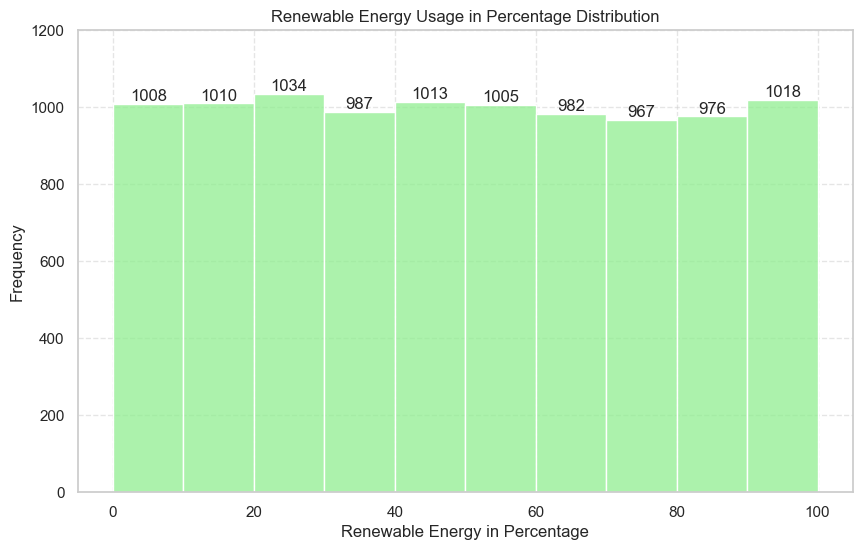

In [94]:
uncleaned_renewable=uncleaned_data[" Renewable_Energy_Usage_percent"]
plt.figure(figsize=(10,6))
ax=sns.histplot(uncleaned_renewable,bins=10, color='lightgreen')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Renewable Energy Usage in Percentage Distribution")
plt.xlabel("Renewable Energy in Percentage")
plt.yticks(range(0,1400,200))
plt.ylabel("Frequency")
plt.grid(True,linestyle='--',alpha=0.5)
plt.show()

**Histogram – Renewable Energy Usage (%)**

* **Range:** Renewable energy usage spans from **0% to 100%**.
* **Distribution:** Bars are **fairly even across all bins**, indicating a **uniform distribution**.
* **Frequency:** Each range has roughly **~970–1030 observations**, showing **no dominant percentage range**.
* **Pattern:** Renewable energy usage is **evenly spread across low, medium, and high percentages**, with **no clear concentration or skewness**.


### Building Type

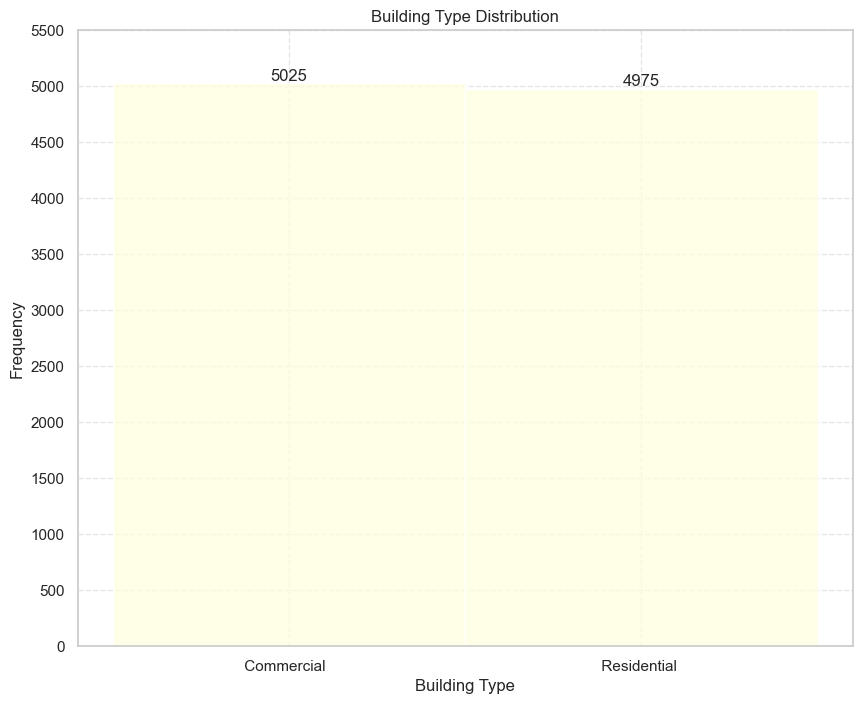

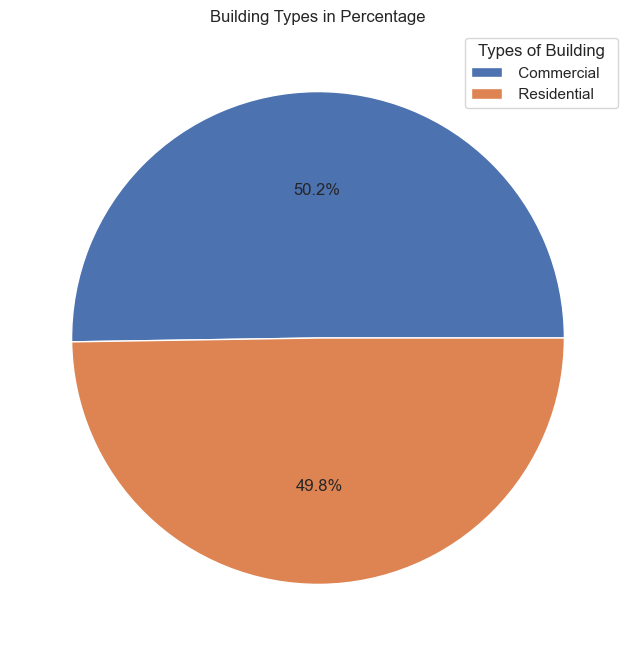

In [95]:
# Histogram for Building Type
uncleaned_building=uncleaned_data[" Building_Type"]
plt.figure(figsize=(10,8))
ax=sns.histplot(uncleaned_building,color='lightyellow')
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("Building Type")
plt.ylabel("Frequency")
plt.yticks(range(0,6000,500))
plt.title("Building Type Distribution")
plt.grid(True,linestyle='--',alpha=0.5)
plt.show()

# Pie Chart for Building Type
building_counts=uncleaned_building.value_counts()
plt.figure(figsize=(10,8))
plt.pie(building_counts,autopct='%1.1f%%')
plt.title("Building Types in Percentage")
plt.legend(building_counts.index,title=("Types of Building"))
plt.show()

**Histogram – Building Type Distribution**

* **Commercial buildings:** ~**5025**, slightly higher frequency.
* **Residential buildings:** ~**4975**, very close to commercial.
* **Distribution:** Both categories have **almost equal counts**.
* **Pattern:** The dataset shows a **balanced distribution between commercial and residential buildings**, with no dominant building type.

**Pie Chart – Building Type Distribution**

* **Commercial buildings:** ~**50.2%**, slightly the **largest proportion**.
* **Residential buildings:** ~**49.8%**, almost equal to commercial.
* **Overall pattern:** The dataset shows a **nearly perfect balance between commercial and residential buildings**.
* **Difference:** The proportion difference is **very small (~0.4%)**, indicating **no dominant building type**.


### Humidity

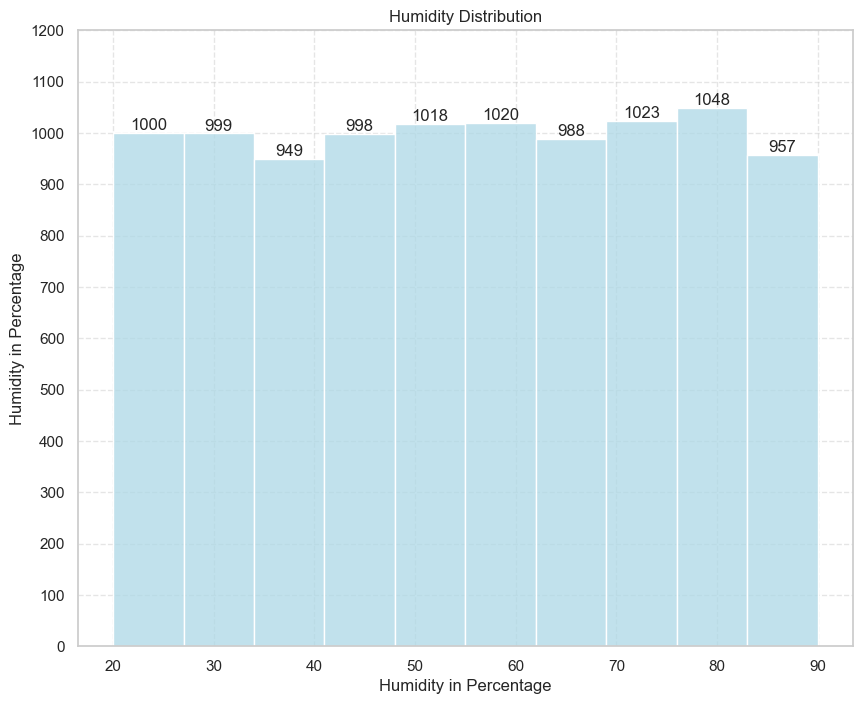

In [96]:
uncleaned_humid=uncleaned_data[" Humidity_percent  "]
plt.figure(figsize=(10,8))
ax=sns.histplot(uncleaned_humid,bins=10,color='lightblue')
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel("Humidity in Percentage")
plt.ylabel("Humidity in Percentage")
plt.yticks(range(0,1300,100))
plt.title("Humidity Distribution")
plt.grid(True,linestyle='--',alpha=0.5)
plt.show()

**Histogram – Humidity Distribution (%)**

* **Range:** Humidity values span roughly from **20% to 90%**.
* **Distribution:** Frequencies are **fairly even across all humidity ranges**, indicating a **uniform distribution**.
* **Frequency:** Each bin contains about **~950–1050 observations**, showing **no dominant humidity level**.
* **Pattern:** Humidity levels are **evenly spread from low to high percentages**, with **no strong skewness or concentration in a specific range**.


## Correlation

### Heatmap (For numerical variable)

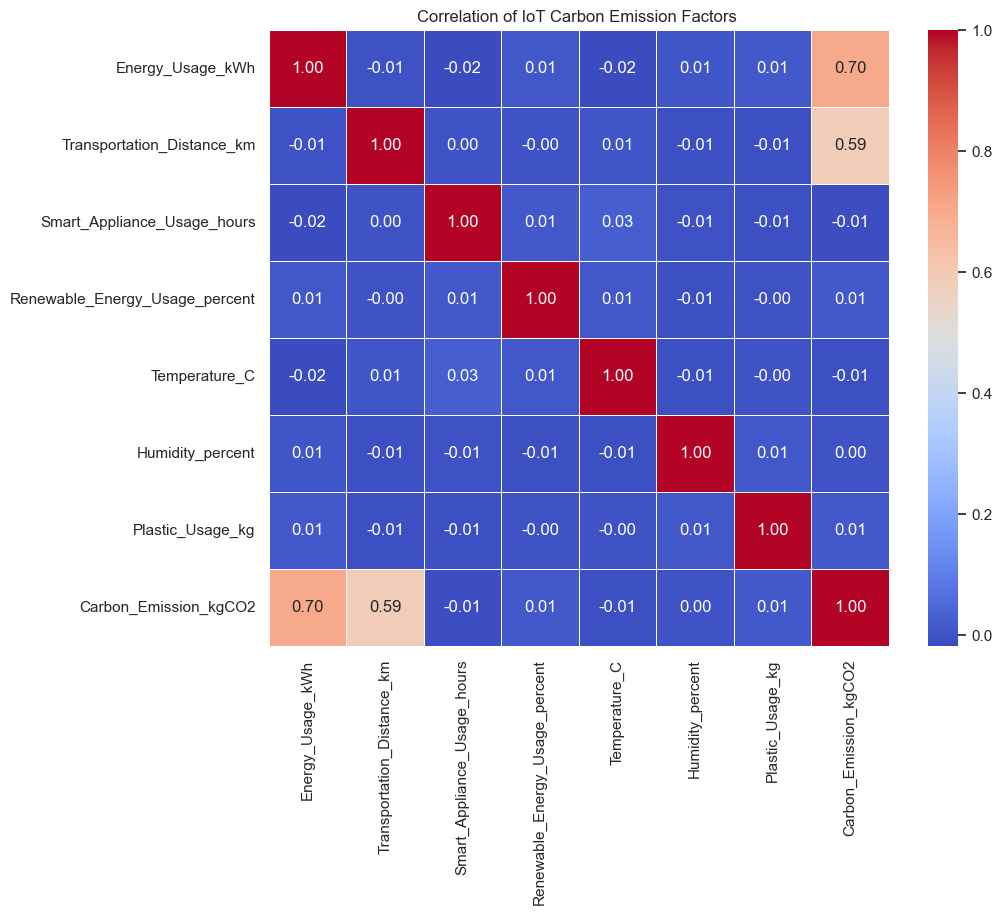

In [97]:
scaled_data.columns=scaled_data.columns.str.strip()
cleaned_numeric=scaled_data.select_dtypes(include='number')
corr=cleaned_numeric.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f',linewidth=0.5)
plt.title("Correlation of IoT Carbon Emission Factors ")
plt.show()


**Heatmap – Correlation of IoT Carbon Emission Factors (Including All Factors)**

* **Strong influence on Carbon Emission:**

  * **Energy_Usage_kWh → 0.70** → strongest factor affecting carbon emissions.
  * **Transportation_Distance_km → 0.59** → second strongest contributor.

* **Very weak relationship with Carbon Emission (≈ 0):**

  * **Smart_Appliance_Usage_hours**
  * **Renewable_Energy_Usage_percent**
  * **Temperature_C**
  * **Humidity_percent**
  * **Plastic_Usage_kg**

* **Interpretation:**

  * **Energy usage and transportation distance remain the main drivers of carbon emissions.**
  * Most other variables show **very low influence and may have limited predictive value** for emissions.
  * **Plastic usage** however is still influencial to our model, despite a low correlation with the target variable, as it's one of the most leading factor in Cambodia specifically.


### Conditional Box plot (For categorical variable)

/var/folders/86/4l8s2b4s5n93y597sjvnw7180000gn/T/ipykernel_3228/198855028.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_var, data=uncleaned_data, palette='Set2')
/var/folders/86/4l8s2b4s5n93y597sjvnw7180000gn/T/ipykernel_3228/198855028.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target_var, data=uncleaned_data, palette='Set2')


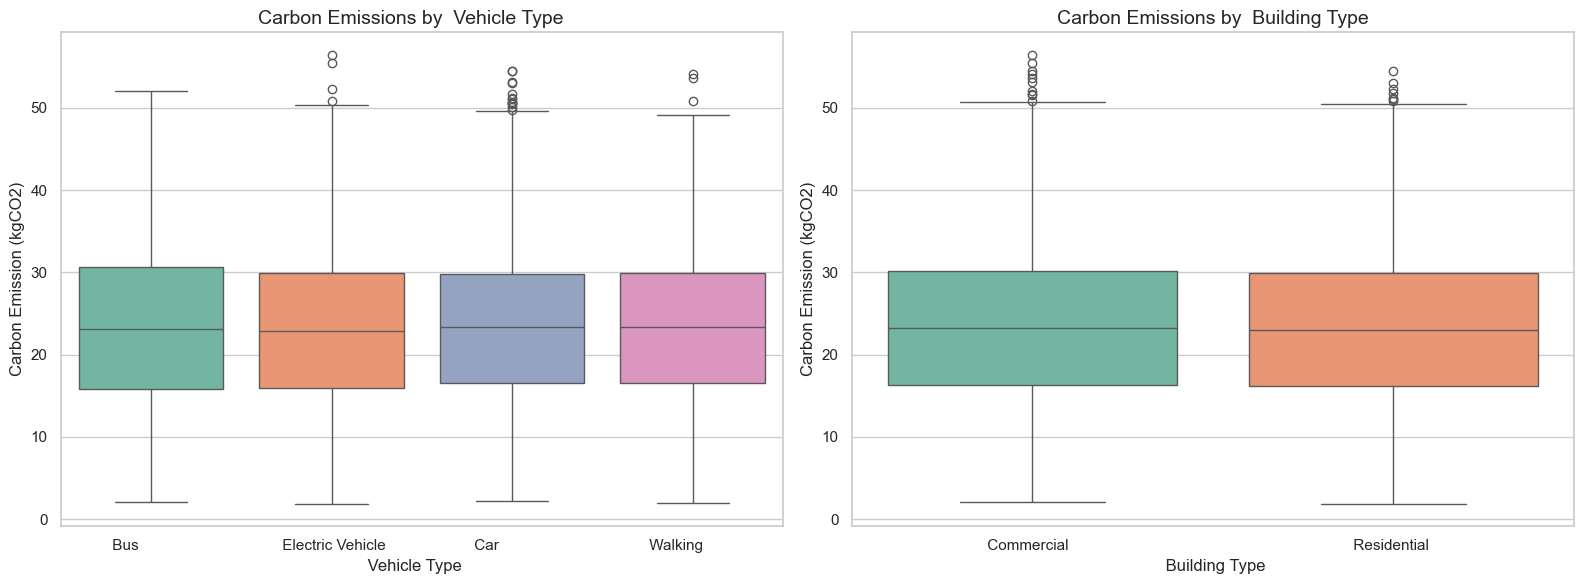

In [98]:
categorical_cols = [' Vehicle_Type    ', ' Building_Type']
target_var = ' Carbon_Emission_kgCO2'
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# Loop through each category to create a boxplot
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(1, 2, i) # 1 row, 2 columns
    sns.boxplot(x=col, y=target_var, data=uncleaned_data, palette='Set2')
    
    # Add labels and styling
    plt.title(f'Carbon Emissions by {col.replace("_", " ")}', fontsize=14)
    plt.xlabel(col.replace("_", " "), fontsize=12)
    plt.ylabel('Carbon Emission (kgCO2)', fontsize=12)
plt.tight_layout()


**Analysis of the Boxplots**

**Weak Association with Target: Contrary to what one might expect in the real world, these categorical variables—Vehicle_Type and Building_Type—show a very weak association with Carbon_Emission_kgCO2.**

**Identical Medians: If you look at the middle line of every box (Bus, EV, Car, Walking, Commercial, Residential), they are all sitting almost exactly at the same level (around $23\text{ kgCO2}$)**

**High Overlap: The boxes (the Interquartile Range) are nearly identical in height and position. This means that a person who walks could easily have the same carbon footprint as someone who drives a car in this specific dataset.**

# Handling Outliers

> No outliers were detected (except for the plastic variable which was a python generative)

# Dataset Finalization

- The target variable is about column : Carbon_Emission_kgCO2
  
- What we want to study on: plastic, electricity, transportation, and airconditioner, so these columns are needed and aren't:
   
  - 'Energy_Usage_kWh' (Needed) 

    - electicity consumption contribute to carbon emissions. 

    - more electricity -> more power generation -> more CO2
  
  - 'Transportation_Distance_km' (Needed)

    - Measures distance of travelling
  
    - longer distance -> more fuel -> more CO2
  
  - 'Plastic_Usage_kg' (Needed)

    - Plastic contribute to carbon emissions (when it's burn)
  
  - 'Carbon_Emission_kgCO2' (Needed) -> Target prediction
    
  - Variables That Are Not Necessary
    - 'Smart_Appliance_Usage_hours' 
    - 'Renewable_Energy_Usage_percent'
    - 'Temperature_C'
    - 'Humidity_percent'
    - 'Building_Type'
    - 'Vehicle_Type'

In [99]:

# Select only the "High-Impact" features and the target variable
selected_columns = [
    ' Energy_Usage_kWh   ', 
    ' Transportation_Distance_km', 
    'Plastic_Usage_kg', 
    ' Carbon_Emission_kgCO2'
]
# Create the filtered DataFrame
df_final_unscaled = uncleaned_data[selected_columns]
output_filename = 'Final_Unscaled_Data.csv'
df_final_unscaled.to_csv(output_filename, index=False)

# Created the scaled dataset ready to be used for machine learning models
df = scaled_data[['Energy_Usage_kWh','Transportation_Distance_km','Plastic_Usage_kg', 'Carbon_Emission_kgCO2']]
df.to_csv("model_ready_dataset.csv", index=False)

In [100]:
df1=pd.read_csv("model_ready_dataset.csv")
df1.head()

,Energy_Usage_kWh,Transportation_Distance_km,Plastic_Usage_kg,Carbon_Emission_kgCO2
0,-0.415900,-0.452465,0.497160,18.593633
1,1.587377,-0.593258,-0.135676,31.748530
2,0.826917,-1.135149,0.647626,22.401654
3,0.363328,0.355146,1.520015,31.058309
4,-1.175669,-0.096466,-0.231242,18.244018
